# Part III: Financial Phrase Sentiment Analysis using RNN, LSTM and Pretrained Embeddings

This notebook is written as an individual, beginner-friendly implementation for the 6CS012 NLP task. It uses the financial phrase dataset and builds three models:

1. Simple RNN with trainable embedding  
2. LSTM with trainable embedding  
3. LSTM with pretrained GloVe/Word2Vec-style embedding  

It also includes preprocessing, tokenization, percentile-based padding, model evaluation, error analysis, and a small Gradio GUI.

## 1. Install and Import Required Libraries

In [1]:
!pip install contractions wordcloud gensim gradio -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 3.3 MB/s eta 0:00:00


In [2]:


import re
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

SEED = 11
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


## 2. Load the Dataset

In [17]:
# Upload the CSV file in Colab, then update the path if needed
DATA_PATH = "/content/drive/MyDrive/Ai Assessment/financial_phrase (1).csv"

data = pd.read_csv(DATA_PATH)

print('Dataset shape:', data.shape)
display(data.head(8))
print('Columns:', list(data.columns))


Dataset shape: (2264, 2)


,text,label
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive
5,Finnish Talentum reports its operating profit ...,positive
6,Clothing retail chain Sepp+ñl+ñ 's sales incre...,positive
7,Consolidated net sales increased 16 % to reach...,positive


Columns: ['text', 'label']


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Select Text and Label Columns

In [11]:
# The dataset already has text and label columns, but this keeps the code flexible
possible_text_columns = ['text', 'sentence', 'tweet', 'review', 'content']
possible_label_columns = ['label', 'sentiment', 'Sentiment', 'category', 'target']

TEXT_COL = next((col for col in possible_text_columns if col in data.columns), None)
LABEL_COL = next((col for col in possible_label_columns if col in data.columns), None)

if TEXT_COL is None or LABEL_COL is None:
    raise ValueError('Text or label column not found. Please set TEXT_COL and LABEL_COL manually.')

# Keep only required columns
data = data[[TEXT_COL, LABEL_COL]].dropna().copy()
data.columns = ['text', 'label']

data['label'] = data['label'].astype(str).str.lower().str.strip()
data['text'] = data['text'].astype(str)

print('Text column used:', TEXT_COL)
print('Label column used:', LABEL_COL)
print('Cleaned dataset shape:', data.shape)
print(data['label'].value_counts())


Text column used: text
Label column used: label
Cleaned dataset shape: (2264, 2)
label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64


## 4. Basic Dataset Visualization

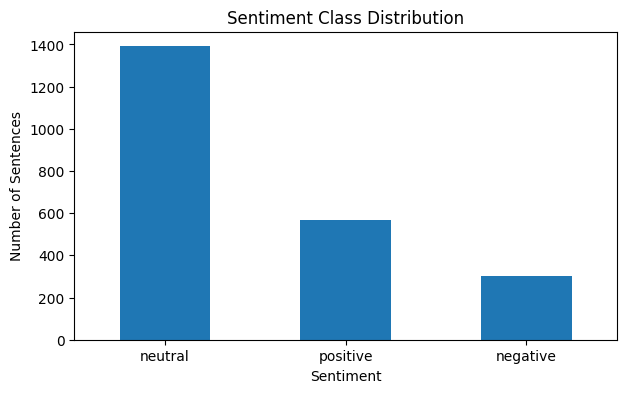

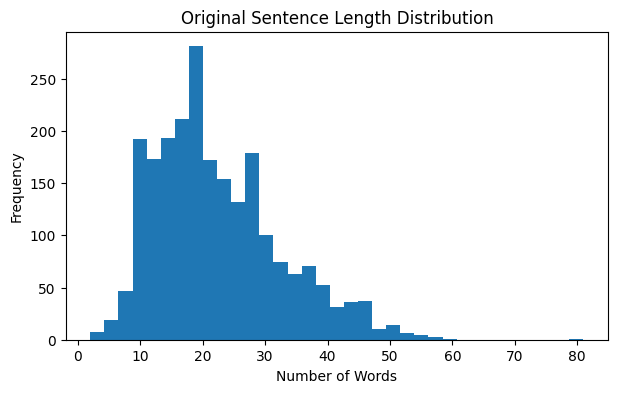

In [12]:
plt.figure(figsize=(7,4))
data['label'].value_counts().plot(kind='bar')
plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Sentences')
plt.xticks(rotation=0)
plt.show()

# Sentence length before cleaning
data['original_word_count'] = data['text'].apply(lambda sentence: len(sentence.split()))

plt.figure(figsize=(7,4))
plt.hist(data['original_word_count'], bins=35)
plt.title('Original Sentence Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()


## 5. Text Preprocessing

In [18]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Keep important negation words because they affect sentiment meaning
important_words = {'not', 'no', 'nor', 'down', 'up', 'gain', 'loss', 'rise', 'fall'}
stop_words = stop_words - important_words

contractions = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "can't": "cannot", "won't": "will not", "isn't": "is not",
    "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "it's": "it is", "i'm": "i am", "you're": "you are",
    "they're": "they are", "we're": "we are", "haven't": "have not",
    "hasn't": "has not", "hadn't": "had not"
}

def preprocess_text(sentence):
    sentence = str(sentence).lower()

    # Expand common contractions
    for short_form, full_form in contractions.items():
        sentence = sentence.replace(short_form, full_form)

    # Remove URLs, mentions, hashtags, numbers and special symbols
    sentence = re.sub(r'http\S+|www\S+', ' ', sentence)
    sentence = re.sub(r'@\w+', ' ', sentence)
    sentence = re.sub(r'#', ' ', sentence)
    sentence = re.sub(r'[^a-z\s]', ' ', sentence)
    sentence = re.sub(r'\s+', ' ', sentence).strip()

    cleaned_words = []
    for word in sentence.split():
        if word not in stop_words:
            cleaned_words.append(lemmatizer.lemmatize(word, pos='v'))

    return ' '.join(cleaned_words)

data['clean_text'] = data['text'].apply(preprocess_text)
data = data[data['clean_text'].str.len() > 0].reset_index(drop=True)

display(data[['text', 'clean_text', 'label']].head(10))
print('Shape after text cleaning:', data.shape)

,text,clean_text,label
0,"According to Gran , the company has no plans t...",accord gran company no plan move production ru...,neutral
1,"For the last quarter of 2010 , Componenta 's n...",last quarter componenta net sales double eur e...,positive
2,"In the third quarter of 2010 , net sales incre...",third quarter net sales increase eur mn operat...,positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,operate profit rise eur mn eur mn correspond p...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",operate profit total eur mn up eur mn represen...,positive
5,Finnish Talentum reports its operating profit ...,finnish talentum report operate profit increas...,positive
6,Clothing retail chain Sepp+ñl+ñ 's sales incre...,clothe retail chain sepp l sales increase eur ...,positive
7,Consolidated net sales increased 16 % to reach...,consolidate net sales increase reach eur opera...,positive
8,Foundries division reports its sales increased...,foundries division report sales increase eur m...,positive
9,"HELSINKI ( AFX ) - Shares closed higher , led ...",helsinki afx share close higher lead nokia ann...,positive


Shape after text cleaning: (2264, 3)


## 6. Visualize Cleaned Text

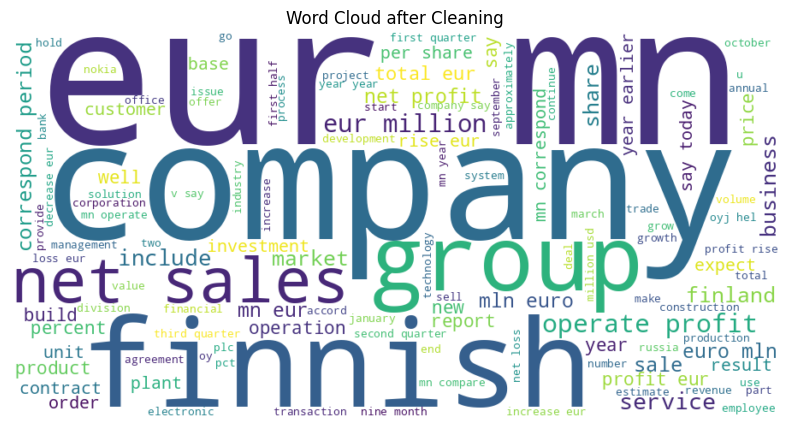

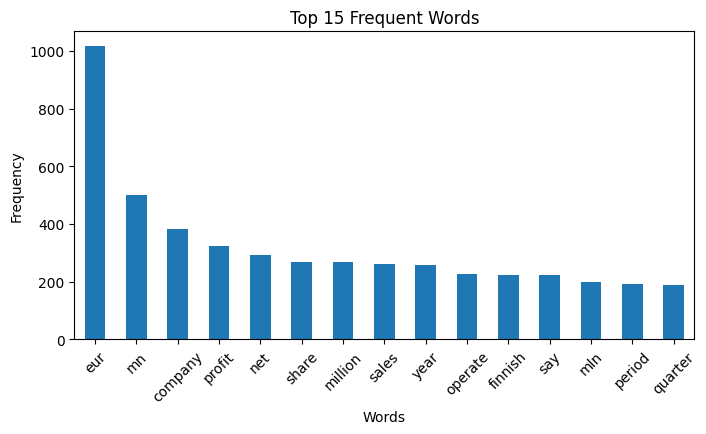

In [19]:
all_clean_words = ' '.join(data['clean_text'])

word_cloud = WordCloud(
    width=900,
    height=450,
    background_color='white',
    max_words=120
).generate(all_clean_words)

plt.figure(figsize=(10,5))
plt.imshow(word_cloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud after Cleaning')
plt.show()

# Most frequent cleaned words
word_series = pd.Series(all_clean_words.split())
common_words = word_series.value_counts().head(15)

plt.figure(figsize=(8,4))
common_words.plot(kind='bar')
plt.title('Top 15 Frequent Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()


## 7. Encode Labels, Tokenize Text and Apply Padding

In [20]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(data['label'])
class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print('Classes:', class_names)
print('Encoded label example:', y[:10])

X_train_text, X_test_text, y_train, y_test = train_test_split(
    data['clean_text'],
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

MAX_WORDS = 9000
EMBED_SIZE = 50
BATCH_SIZE = 32

# Convert words into integer sequences
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_text)

train_sequences = tokenizer.texts_to_sequences(X_train_text)
test_sequences = tokenizer.texts_to_sequences(X_test_text)

# Percentile-based padding avoids setting the sequence length too high
sequence_lengths = [len(seq) for seq in train_sequences]
MAX_LEN = int(np.percentile(sequence_lengths, 95))
MAX_LEN = max(MAX_LEN, 5)

X_train = pad_sequences(train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_test = pad_sequences(test_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)

print('Vocabulary size:', vocab_size)
print('Maximum sequence length:', MAX_LEN)
print('Training data shape:', X_train.shape)
print('Testing data shape:', X_test.shape)


Classes: ['negative', 'neutral', 'positive']
Encoded label example: [1 2 2 2 2 2 2 2 2 2]
Vocabulary size: 3993
Maximum sequence length: 23
Training data shape: (1811, 23)
Testing data shape: (453, 23)


## 8. Helper Functions for Model Training and Evaluation

In [21]:
def output_layer():
    if num_classes == 2:
        return Dense(1, activation='sigmoid')
    return Dense(num_classes, activation='softmax')


def compile_network(model):
    if num_classes == 2:
        loss_function = 'binary_crossentropy'
    else:
        loss_function = 'sparse_categorical_crossentropy'

    model.compile(
        optimizer='adam',
        loss=loss_function,
        metrics=['accuracy']
    )
    return model


def plot_training_result(history, model_title):
    plt.figure(figsize=(7,4))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(model_title + ' Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(model_title + ' Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


def predict_classes(model):
    predictions = model.predict(X_test, verbose=0)
    if num_classes == 2:
        return (predictions.ravel() >= 0.5).astype(int)
    return np.argmax(predictions, axis=1)


def evaluate_network(model, model_title):
    y_pred = predict_classes(model)
    acc = accuracy_score(y_test, y_pred)

    print(model_title, 'Accuracy:', round(acc, 4))
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format='d')
    plt.title(model_title + ' Confusion Matrix')
    plt.show()

    return acc, y_pred


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


## 9. Model 1: Simple RNN with Trainable Embedding Layer

In [22]:
rnn_model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=vocab_size, output_dim=EMBED_SIZE),
    SimpleRNN(50),
    Dropout(0.25),
    Dense(32, activation='relu'),
    output_layer()
], name='Student_Simple_RNN')

compile_network(rnn_model)
rnn_model.summary()


Model: "Student_Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 23, 50)         │       199,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 206,431 (806.37 KB)

 Trainable params: 206,431 (806.37 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6511 - loss: 0.8768 - val_accuracy: 0.6949 - val_loss: 0.7678
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7771 - loss: 0.5455 - val_accuracy: 0.6949 - val_loss: 0.7555
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8415 - loss: 0.3657 - val_accuracy: 0.6801 - val_loss: 0.7326
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8908 - loss: 0.2645 - val_accuracy: 0.6581 - val_loss: 0.8807
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9318 - loss: 0.1766 - val_accuracy: 0.6250 - val_loss: 1.0474
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9571 - loss: 0.1307 - val_accuracy: 0.6654 - val_loss: 1.0363


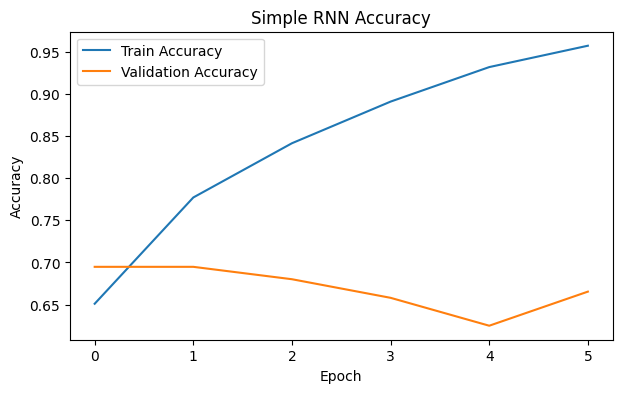

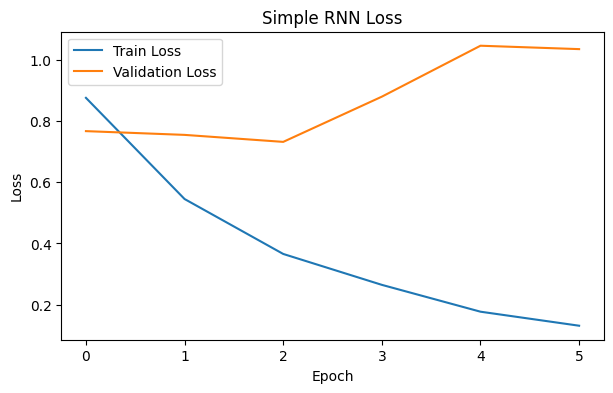

Simple RNN Accuracy: 0.7086
              precision    recall  f1-score   support

    negative       0.12      0.05      0.07        61
     neutral       0.88      0.88      0.88       278
    positive       0.49      0.64      0.56       114

    accuracy                           0.71       453
   macro avg       0.50      0.52      0.50       453
weighted avg       0.68      0.71      0.69       453



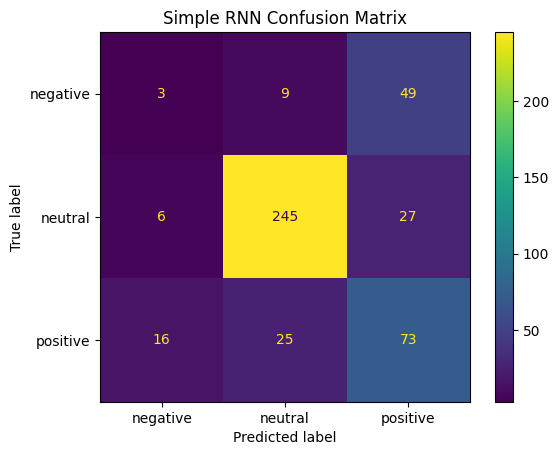

Training time: 6.61 seconds


In [23]:
start_time = time.time()

rnn_history = rnn_model.fit(
    X_train,
    y_train,
    validation_split=0.15,
    epochs=10,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

rnn_training_time = time.time() - start_time

plot_training_result(rnn_history, 'Simple RNN')
rnn_accuracy, rnn_predictions = evaluate_network(rnn_model, 'Simple RNN')
print('Training time:', round(rnn_training_time, 2), 'seconds')


## 10. Model 2: LSTM with Trainable Embedding Layer

In [24]:
lstm_model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=vocab_size, output_dim=EMBED_SIZE),
    LSTM(64),
    Dropout(0.30),
    Dense(40, activation='relu'),
    output_layer()
], name='Student_LSTM_Model')

compile_network(lstm_model)
lstm_model.summary()


Model: "Student_LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 23, 50)         │       199,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 40)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           123 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 231,813 (905.52 KB)

 Trainable params: 231,813 (905.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.6101 - loss: 0.9424 - val_accuracy: 0.5809 - val_loss: 0.9498
Epoch 2/12
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6940 - loss: 0.6981 - val_accuracy: 0.7279 - val_loss: 0.6859
Epoch 3/12
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8018 - loss: 0.4398 - val_accuracy: 0.7316 - val_loss: 0.6465
Epoch 4/12
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8343 - loss: 0.3486 - val_accuracy: 0.7243 - val_loss: 0.6947
Epoch 5/12
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8493 - loss: 0.3141 - val_accuracy: 0.7316 - val_loss: 0.7279
Epoch 6/12
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8590 - loss: 0.2925 - val_accuracy: 0.7426 - val_loss: 0.7456


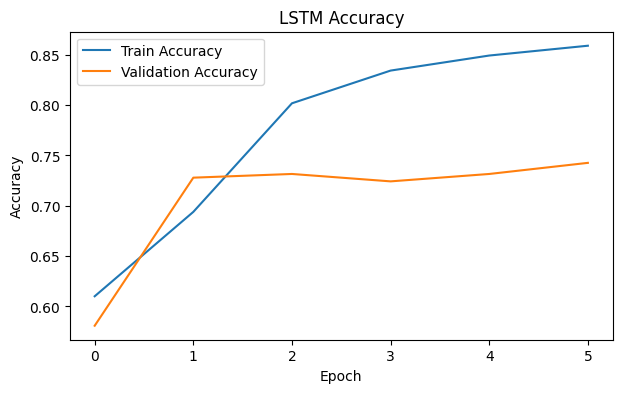

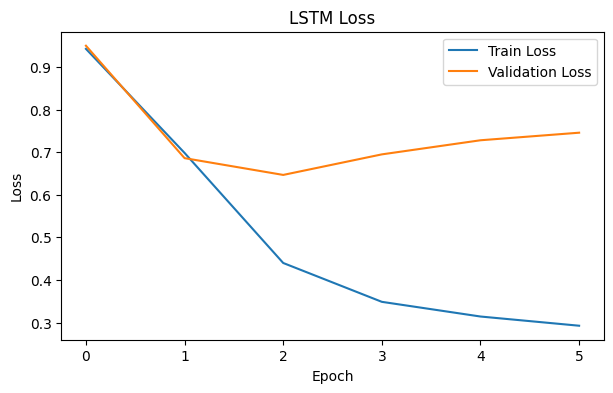

LSTM Accuracy: 0.7373
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        61
     neutral       0.94      0.84      0.88       278
    positive       0.50      0.89      0.64       114

    accuracy                           0.74       453
   macro avg       0.48      0.57      0.51       453
weighted avg       0.70      0.74      0.70       453



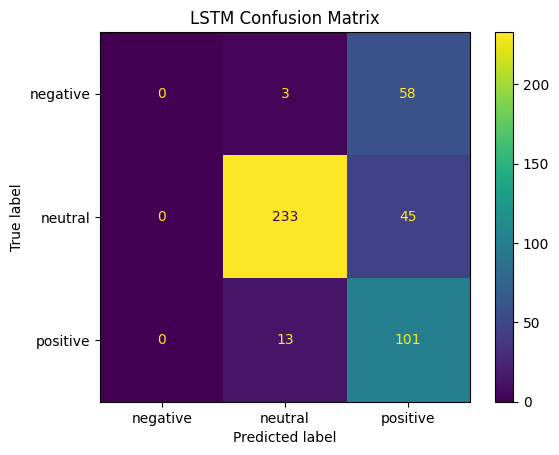

Training time: 8.72 seconds


In [25]:
start_time = time.time()

lstm_history = lstm_model.fit(
    X_train,
    y_train,
    validation_split=0.15,
    epochs=12,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

lstm_training_time = time.time() - start_time

plot_training_result(lstm_history, 'LSTM')
lstm_accuracy, lstm_predictions = evaluate_network(lstm_model, 'LSTM')
print('Training time:', round(lstm_training_time, 2), 'seconds')


## 11. Model 3: LSTM with Pretrained GloVe / Word2Vec-style Embeddings

In [26]:
# Train Word2Vec using cleaned training text
from gensim.models import Word2Vec

word2vec_sentences = [text.split() for text in X_train_text]

WORD2VEC_DIM = 100

word2vec_model = Word2Vec(
    sentences=word2vec_sentences,
    vector_size=WORD2VEC_DIM,
    window=5,
    min_count=1,
    workers=4,
    sg=1,
    seed=SEED
)

print("Word2Vec model trained successfully.")
print("Word2Vec vocabulary size:", len(word2vec_model.wv))

Word2Vec model trained successfully.
Word2Vec vocabulary size: 3991


In [29]:

embedding_matrix = np.zeros((vocab_size, WORD2VEC_DIM))
matched_count = 0

for word, idx in tokenizer.word_index.items():
    if idx >= vocab_size:
        continue

    if word in word2vec_model.wv:
        embedding_matrix[idx] = word2vec_model.wv[word]
        matched_count += 1

coverage = (matched_count / vocab_size) * 100

print('Matched words:', matched_count)
print('Embedding coverage:', round(coverage, 2), '%')
print('Embedding matrix shape:', embedding_matrix.shape)

Matched words: 3991
Embedding coverage: 99.95 %
Embedding matrix shape: (3993, 100)


In [30]:
# LSTM model using Word2Vec embedding
word2vec_lstm_model = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=WORD2VEC_DIM,
        weights=[embedding_matrix],
        trainable=False
    ),

    Bidirectional(LSTM(48)),
    Dropout(0.30),
    Dense(36, activation='relu'),
    output_layer()
], name='Student_Word2Vec_LSTM')

compile_network(word2vec_lstm_model)
word2vec_lstm_model.summary()

Model: "Student_Word2Vec_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 23, 100)        │       399,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 96)             │        57,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 36)             │         3,492 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           111 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 460,119 (1.76 MB)

 Trainable params: 60,819 (237.57 KB)

 Non-trainable params: 399,300 (1.52 MB)

Epoch 1/12
49/49 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - accuracy: 0.6881 - loss: 0.7956 - val_accuracy: 0.6912 - val_loss: 0.8041
Epoch 2/12
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.7303 - loss: 0.6613 - val_accuracy: 0.6985 - val_loss: 0.7469
Epoch 3/12
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.7375 - loss: 0.6484 - val_accuracy: 0.6985 - val_loss: 0.7348


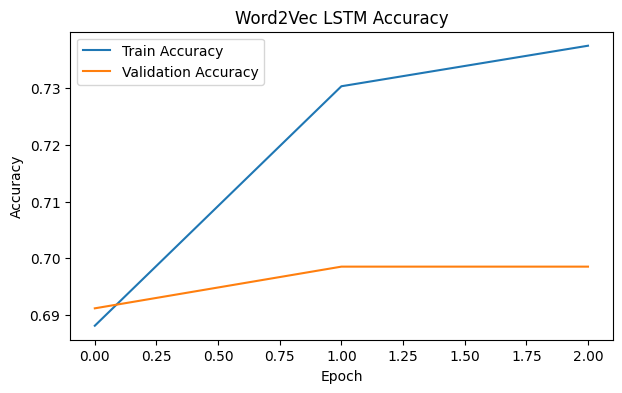

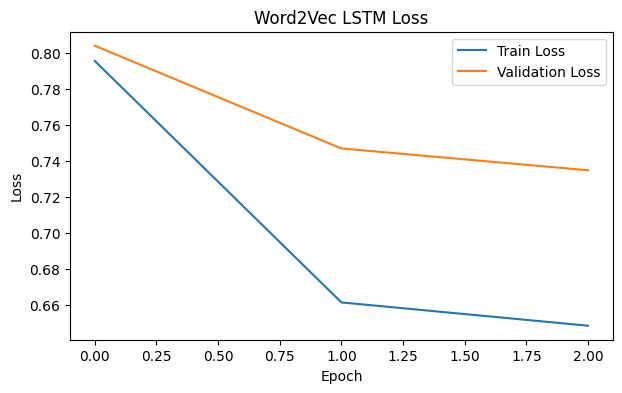

Word2Vec LSTM Accuracy: 0.7196
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        61
     neutral       0.76      0.97      0.86       278
    positive       0.56      0.49      0.52       114

    accuracy                           0.72       453
   macro avg       0.44      0.49      0.46       453
weighted avg       0.61      0.72      0.66       453



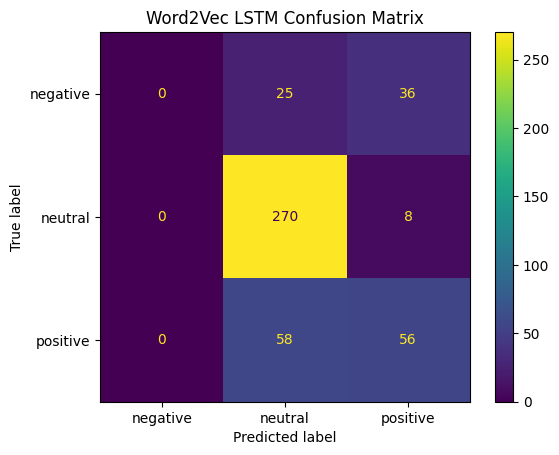

Training time: 16.83 seconds


In [31]:
start_time = time.time()

word2vec_history = word2vec_lstm_model.fit(
    X_train,
    y_train,
    validation_split=0.15,
    epochs=12,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

word2vec_training_time = time.time() - start_time

plot_training_result(word2vec_history, 'Word2Vec LSTM')

word2vec_accuracy, word2vec_predictions = evaluate_network(
    word2vec_lstm_model,'Word2Vec LSTM')

print('Training time:', round(word2vec_training_time, 2), 'seconds')

## 12. Compare All Models

                       Model  Accuracy  Training Time (seconds)
0                 Simple RNN  0.708609                 6.605686
1                       LSTM  0.737307                 8.717332
2  Pretrained Embedding LSTM  0.719647                16.830175


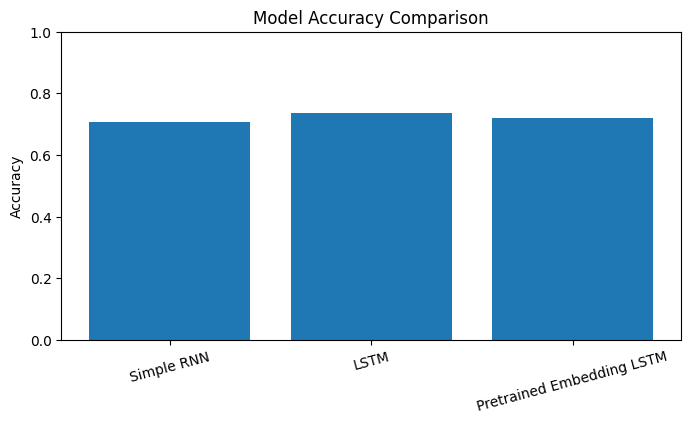

Best model: LSTM


In [33]:
model_results = pd.DataFrame({
    'Model': ['Simple RNN', 'LSTM', 'Pretrained Embedding LSTM'],
    'Accuracy': [rnn_accuracy, lstm_accuracy, word2vec_accuracy],
    'Training Time (seconds)': [rnn_training_time, lstm_training_time,  word2vec_training_time]
})

print(model_results)

plt.figure(figsize=(8,4))
plt.bar(model_results['Model'], model_results['Accuracy'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

best_index = model_results['Accuracy'].idxmax()
best_model_name = model_results.loc[best_index, 'Model']
print('Best model:', best_model_name)


## 13. Error Analysis: Show Incorrect Predictions

In [34]:
# Select the prediction array of the best model
if best_model_name == 'Simple RNN':
    final_model = rnn_model
    final_predictions = rnn_predictions

elif best_model_name == 'LSTM':
    final_model = lstm_model
    final_predictions = lstm_predictions

else:
    final_model = word2vec_lstm_model
    final_predictions = word2vec_predictions

wrong_indices = np.where(final_predictions != y_test)[0]

print('Total wrong predictions:', len(wrong_indices))

for count, idx in enumerate(wrong_indices[:3], start=1):
    print('Wrong Prediction', count)
    print('Text:', X_test_text.iloc[idx])
    print('Actual Label:', class_names[y_test[idx]])
    print('Predicted Label:', class_names[final_predictions[idx]])
    print('-' * 50)

Total wrong predictions: 119
Wrong Prediction 1
Text: eur million non recur expense record third quarter
Actual Label: neutral
Predicted Label: positive
--------------------------------------------------
Wrong Prediction 2
Text: castecka say town hall would hold talk investors interest zone
Actual Label: neutral
Predicted Label: positive
--------------------------------------------------
Wrong Prediction 3
Text: dealers say share largely hit investor disappointment refine margin usd per barrel quarter performance ship unit saw ebit drop mln eur mln eur year amid fall volumes tanker rat
Actual Label: negative
Predicted Label: positive
--------------------------------------------------


## 14. Single Text Prediction Function

In [35]:
def predict_sentiment(sentence):
    cleaned_sentence = preprocess_text(sentence)
    sequence = tokenizer.texts_to_sequences([cleaned_sentence])
    padded_sequence = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')

    prediction = final_model.predict(padded_sequence, verbose=0)

    if num_classes == 2:
        predicted_id = int(prediction[0][0] >= 0.5)
        confidence = prediction[0][0] if predicted_id == 1 else 1 - prediction[0][0]
    else:
        predicted_id = int(np.argmax(prediction[0]))
        confidence = float(np.max(prediction[0]))

    return class_names[predicted_id], round(confidence * 100, 2)

# Test examples
examples = [
    'The company reported strong profit growth this year.',
    'The firm suffered a major loss in the last quarter.',
    'The company held its annual general meeting today.'
]

for example in examples:
    label, confidence = predict_sentiment(example)
    print(example)
    print('Prediction:', label, '| Confidence:', confidence, '%')
    print('-' * 60)


The company reported strong profit growth this year.
Prediction: positive | Confidence: 61.24 %
------------------------------------------------------------
The firm suffered a major loss in the last quarter.
Prediction: positive | Confidence: 53.34 %
------------------------------------------------------------
The company held its annual general meeting today.
Prediction: neutral | Confidence: 98.68 %
------------------------------------------------------------


## 15. Simple Gradio GUI for Real-time Prediction

In [ ]:
import gradio as gr

def gradio_predict(user_text):
    label, confidence = predict_sentiment(user_text)
    return f'Predicted sentiment: {label} | Confidence: {confidence}%'

app = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Textbox(
        lines=3,
        placeholder='Enter a financial sentence here...'
    ),
    outputs='text',
    title='Financial Sentiment Classifier',
    description='Predicts negative, neutral, or positive sentiment.'
)

app.launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d05e9e59cdf9ea7acb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 16. Short Conclusion for Report

In [ ]:
print('Conclusion:')
print('This project implemented three deep learning models for financial sentiment classification.')
print('The models were compared using accuracy, classification report, confusion matrix and training time.')
print('The pretrained embedding LSTM uses external word vectors, while the other two models learn embeddings from the dataset.')
print('Misclassified examples show that short or ambiguous financial sentences are harder to classify correctly.')


Conclusion:
This project implemented three deep learning models for financial sentiment classification.
The models were compared using accuracy, classification report, confusion matrix and training time.
The pretrained embedding LSTM uses external word vectors, while the other two models learn embeddings from the dataset.
Misclassified examples show that short or ambiguous financial sentences are harder to classify correctly.
